In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign


In [5]:
import os

print(os.listdir(path))

['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [6]:
print(os.listdir(path + "/Train")[:5])
print(os.listdir(path + "/train")[:5])

['7', '17', '19', '22', '2']
['7', '17', '19', '22', '2']


In [10]:
import os
import numpy as np
from PIL import Image

# Base path (your Kaggle path)
base_dir = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train"

images = []
labels = []

IMG_HEIGHT = 32
IMG_WIDTH = 32

# Loop through class folders (0–42)
for label in range(43):
    class_path = os.path.join(base_dir, str(label))
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        try:
            img = Image.open(img_path).resize((IMG_HEIGHT, IMG_WIDTH))
            img = np.array(img)
            
            images.append(img)
            labels.append(label)
        
        except:
            continue  # skip corrupted images

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

print("Total images:", len(images))
print("Total labels:", len(labels))

Total images: 39207
Total labels: 39207


# Convert labels for cnn

In [ ]:
from tensorflow.keras.utils import to_categorical

labels = to_categorical(labels, 43)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    images, labels, test_size=0.2, random_state=42
)
#Normalize the images
X_train = X_train / 255.0
X_val = X_val / 255.0

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10)

# Dataset Loading

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_HEIGHT = 32
IMG_WIDTH = 32

train_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

2026-04-12 13:57:42.823353: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776002263.068784     174 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776002263.150000     174 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776002263.770293     174 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776002263.770347     174 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776002263.770350     174 computation_placer.cc:177] computation placer alr

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


# Preprocessing

In [2]:
datagen = ImageDataGenerator(
    rescale=1./255,   # normalization
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=(30, 30),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 31368 images belonging to 43 classes.


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')  # GTSRB has 43 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-12 14:04:06.598382: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

# Train the model

In [7]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# 2. IMAGE SIZE
# ==============================
IMG_HEIGHT = 30
IMG_WIDTH = 30

# ==============================
# 3. LOAD DATASET (GENERATOR)
# ==============================
train_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train"
test_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# ==============================
# 4. BUILD CNN MODEL
# ==============================
model = Sequential()

# 1st Conv Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Conv Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 3rd Conv Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output Layer (43 classes)
model.add(Dense(43, activation='softmax'))

# ==============================
# 5. COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model structure
model.summary()

# ==============================
# 6. TRAIN MODEL
# ==============================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

# ==============================
# 7. TEST DATA (EVALUATION)
# ==============================
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

#test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,627 (920.42 KB)

 Trainable params: 235,627 (920.42 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 63s 63ms/step - accuracy: 0.3228 - loss: 2.4708 - val_accuracy: 0.8079 - val_loss: 0.6648
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 55s 56ms/step - accuracy: 0.8904 - loss: 0.3436 - val_accuracy: 0.8896 - val_loss: 0.4074
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 54s 55ms/step - accuracy: 0.9507 - loss: 0.1588 - val_accuracy: 0.9170 - val_loss: 0.3093
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 55s 57ms/step - accuracy: 0.9725 - loss: 0.0901 - val_accuracy: 0.9161 - val_loss: 0.2834
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.9765 - loss: 0.0735 - val_accuracy: 0.9194 - val_loss: 0.2968
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.9817 - loss: 0.0547 - val_accuracy: 0.9228 - val_loss: 0.3134
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.9858 - loss: 0.0469 - val_accuracy: 0.9288 - val_loss: 0.3229
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - accuracy: 0.9870 - loss: 0.0415 - 

NameError: name 'test_acc' is not defined

# LeNet

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# Build LeNet-5 model for GTSRB
model = Sequential()

# 1st Conv Layer
model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(30,30,3)))
model.add(AveragePooling2D(pool_size=(2,2)))

# 2nd Conv Layer
model.add(Conv2D(16, (5,5), activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))

# Output Layer (43 classes)
model.add(Dense(43, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

# Train (IMPORTANT: use generator, not arrays)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 9, 9, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 43)             │         3,655 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,531 (185.67 KB)

 Trainable params: 47,531 (185.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 61s 60ms/step - accuracy: 0.5166 - loss: 1.8462 - val_accuracy: 0.7947 - val_loss: 0.6906
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step - accuracy: 0.9107 - loss: 0.3404 - val_accuracy: 0.8354 - val_loss: 0.5546
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.9469 - loss: 0.2023 - val_accuracy: 0.8459 - val_loss: 0.5166
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 60s 61ms/step - accuracy: 0.9638 - loss: 0.1356 - val_accuracy: 0.8720 - val_loss: 0.4408
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 51s 52ms/step - accuracy: 0.9768 - loss: 0.0942 - val_accuracy: 0.8561 - val_loss: 0.5171
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.9814 - loss: 0.0717 - val_accuracy: 0.8642 - val_loss: 0.4978
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 54s 55ms/step - accuracy: 0.9858 - loss: 0.0563 - val_accuracy: 0.8714 - val_loss: 0.4556
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.9880 - loss: 0.0439 - 

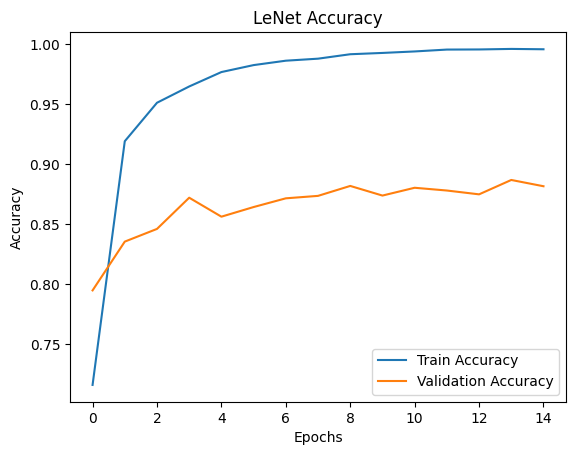

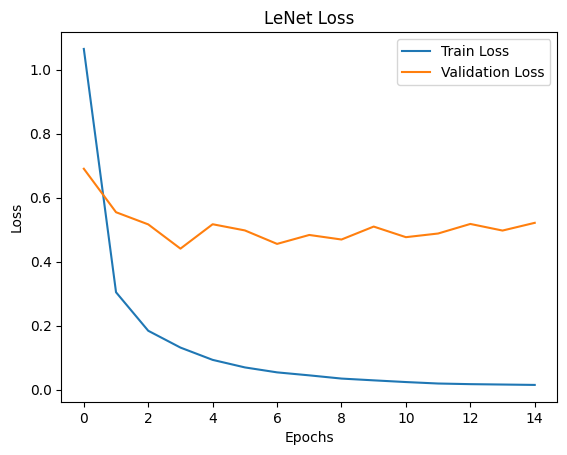

In [11]:
# ==============================
# PLOT ACCURACY GRAPH
# ==============================
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LeNet Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

# ==============================
# PLOT LOSS GRAPH
# ==============================
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LeNet Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


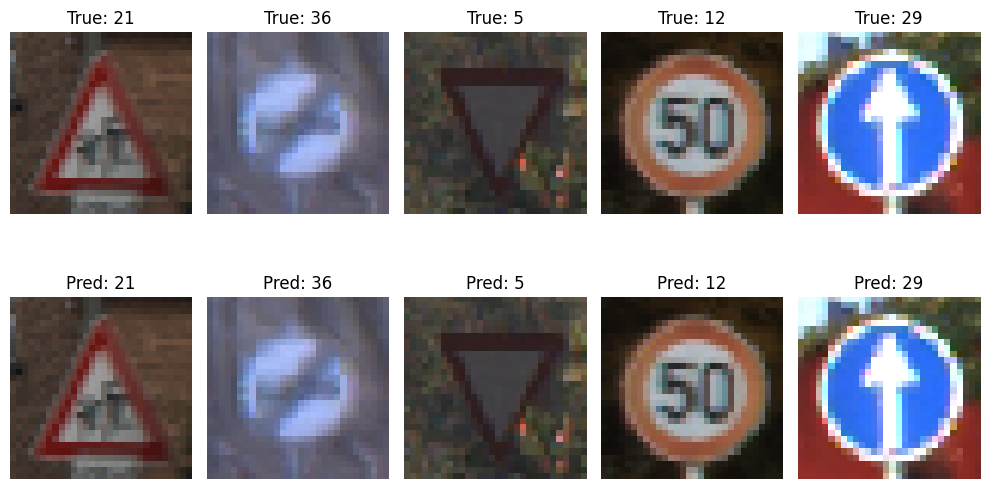

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from generator
images, labels = next(train_data)

# Predict using LeNet model
predictions = model.predict(images)

# Show 5 images
plt.figure(figsize=(10,6))

for i in range(5):
    plt.subplot(2,5,i+1)
    
    # BEFORE (original from dataset - already resized by generator)
    plt.imshow(images[i])
    plt.title(f"True: {np.argmax(labels[i])}")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    
    # AFTER (prediction)
    plt.imshow(images[i])
    pred_class = np.argmax(predictions[i])
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Shows that LeNet predicted correctly

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


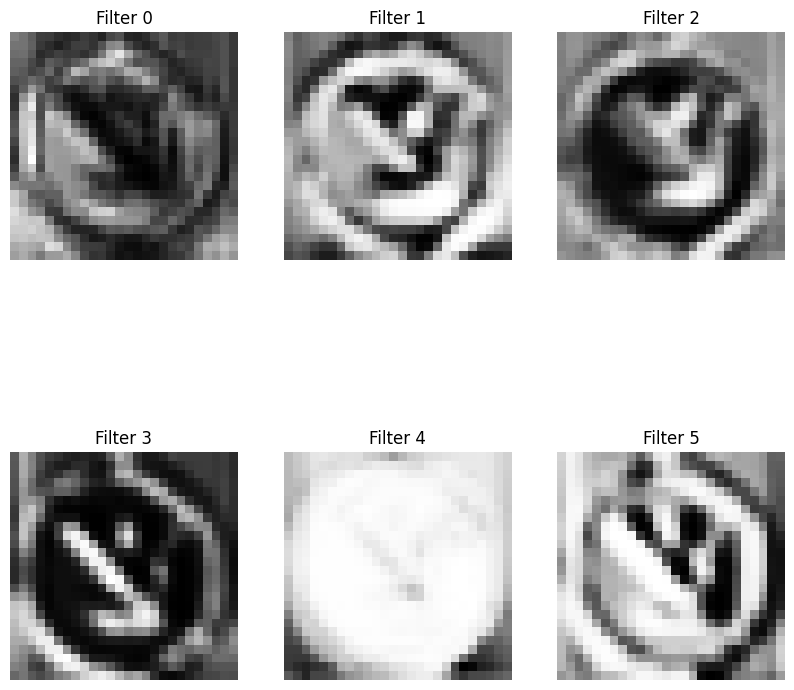

In [17]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Get one batch
images, labels = next(train_data)
img = images[0]

# Create activation model (FIX HERE 👇)
layer_outputs = [layer.output for layer in model.layers[:2]]
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

# Prepare image
img = img.reshape(1, 30, 30, 3)

# Get feature maps
activations = activation_model.predict(img)

# Plot feature maps
feature_maps = activations[0]

plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='gray')
    plt.title(f'Filter {i}')
    plt.axis('off')

plt.show()

Shows all the 6 filters applied on the image after the first convolutional
* 1 is edges
* 2 is circular boundary
* 3 is contrast
* 4 is textures
* 5 is shapes
* 6 is highlights

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


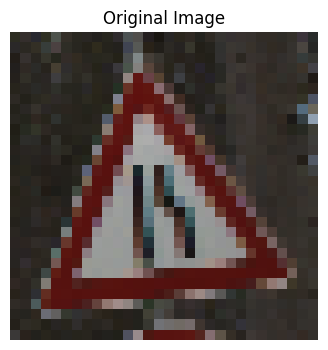

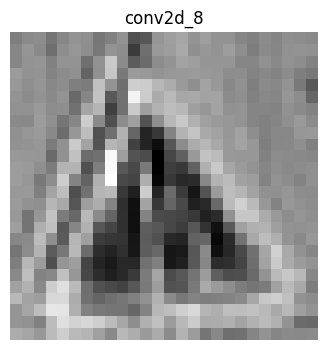

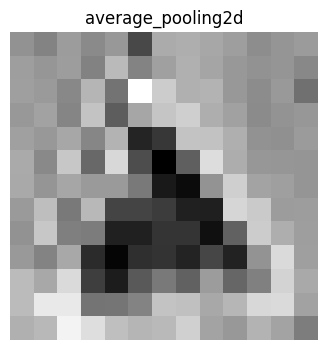

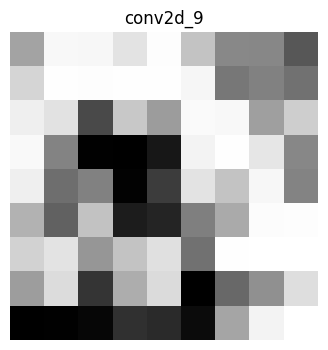

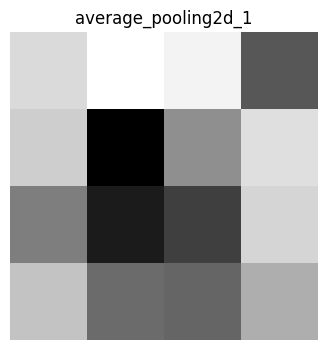

In [28]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
import numpy as np

# Get ONE image (not all)
images, labels = next(train_data)
img = images[1]

# Create model to get outputs of each layer
layer_outputs = [layer.output for layer in model.layers]
activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

# Prepare image
img_input = img.reshape(1, 30, 30, 3)

# Get activations
activations = activation_model.predict(img_input)

# ==============================
# SHOW ORIGINAL IMAGE
# ==============================
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

# ==============================
# SHOW EACH LAYER OUTPUT
# ==============================
layer_names = [layer.name for layer in model.layers]

for layer_name, activation in zip(layer_names, activations):

    # Skip non-image layers
    if len(activation.shape) != 4:
        continue

    feature_map = activation[0, :, :, 0]  # first filter

    plt.figure(figsize=(4,4))
    plt.imshow(feature_map, cmap='gray')
    plt.title(f"{layer_name}")
    plt.axis('off')
    plt.show()

Shows the image after each layer in lenet

# AlexNet